# Task 2.1 — Dataset Selection and Setup (5 marks)

**Paper:** Kernel Latent SVM for Visual Recognition (NeurIPS 2012)

---

## Dataset Choice: CIFAR-10

We use the **CIFAR-10 dataset** for reproducing the latent subcategory experiment from Section 4.2 of the paper. CIFAR-10 consists of 60,000 32×32 colour images in 10 classes. This is the same dataset used in the paper, making it a direct reproduction target. The paper uses HOG features extracted from images and treats the subcategory identity as a latent variable with |H_c| = 3 subcategories per class.

**Why it is a reasonable testbed:** CIFAR-10 was explicitly used in the paper's Section 4.2 experiment on object classification with latent subcategories. Each class (e.g., "bird", "boat") contains images with significant intra-class variation in viewpoint, pose, and background, which is precisely the type of variation that latent subcategories are designed to capture. The dataset has well over 100 samples per class and multiple features can be extracted from each image.

**Limitations compared to the original paper experiment:** We use a subset of CIFAR-10 (due to computational constraints of running kernel SVM on the full dataset, which requires O(n^2) kernel matrix computation). The paper uses the full 50,000 training images split into 5 batches of 10,000; we use a smaller subset. Additionally, we use scikit-learn's SVM implementation rather than the custom solver the authors likely used.

---

## Preprocessing Steps

1. Load CIFAR-10 training and test sets
2. Select a subset of classes and samples for computational feasibility
3. Convert images to grayscale
4. Extract HOG (Histogram of Oriented Gradients) features from each image
5. Normalize features to unit L2 norm (as assumed in the paper, Section 3.1)
6. Set random seeds for reproducibility

In [2]:
import os
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# ============================================================
# Random Seeds and Configuration
# ============================================================
import numpy as np
import warnings
warnings.filterwarnings("ignore")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Hyperparameters (all defined in one place)
NUM_CLASSES_SUBSET = 4        # Number of CIFAR-10 classes to use
SAMPLES_PER_CLASS_TRAIN = 200 # Training samples per class
SAMPLES_PER_CLASS_TEST = 100  # Test samples per class
NUM_SUBCATEGORIES = 3         # |H_c| = 3 as in the paper (Section 4.2)
C1 = 0.01                     # Regularization for positives (paper: C1=C2=0.01)
C2 = 0.01                     # Regularization for negatives
MAX_ITER = 5                  # Max alternating optimization iterations
HOG_ORIENTATIONS = 8
HOG_PIXELS_PER_CELL = (8, 8)
HOG_CELLS_PER_BLOCK = (2, 2)

SELECTED_CLASSES = [0, 1, 2, 3]  # airplane, automobile, bird, cat
CLASS_NAMES = ["airplane", "automobile", "bird", "cat"]

print(f"Random seed: {RANDOM_SEED}")
print(f"Classes: {CLASS_NAMES}")
print(f"Subcategories per class: {NUM_SUBCATEGORIES}")
print(f"C1 = C2 = {C1}")

Random seed: 42
Classes: ['airplane', 'automobile', 'bird', 'cat']
Subcategories per class: 3
C1 = C2 = 0.01


The above cell sets all hyperparameters in one place. The values of  and  are taken directly from Section 4.2 of the paper.

In [5]:
# ============================================================
# Load CIFAR-10 and Extract HOG Features
# ============================================================
from skimage.feature import hog
from skimage.color import rgb2gray
import matplotlib.pyplot as plt

print("Loading CIFAR-10...")
# ============================================================
# Robust CIFAR-10 Loading
# ============================================================
import pickle
import urllib.request
import tarfile
import os
import shutil

def load_cifar10(data_dir='/tmp/cifar10'):
    """Download and load CIFAR-10 dataset directly from source."""
    url = 'https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz'
    tar_path = os.path.join(data_dir, 'cifar-10-python.tar.gz')
    extract_dir = os.path.join(data_dir, 'cifar-10-batches-py')
    
    if not os.path.exists(extract_dir):
        os.makedirs(data_dir, exist_ok=True)
        print('Downloading CIFAR-10...')
        urllib.request.urlretrieve(url, tar_path)
        print('Extracting...')
        with tarfile.open(tar_path, 'r:gz') as tar:
            tar.extractall(data_dir)
        os.remove(tar_path)
    
    # Load training batches
    X_train_list, y_train_list = [], []
    for i in range(1, 6):
        batch_file = os.path.join(extract_dir, f'data_batch_{i}')
        with open(batch_file, 'rb') as f:
            batch = pickle.load(f, encoding='bytes')
        X_train_list.append(batch[b'data'])
        y_train_list.extend(batch[b'labels'])
    
    # Load test batch
    test_file = os.path.join(extract_dir, 'test_batch')
    with open(test_file, 'rb') as f:
        test_batch = pickle.load(f, encoding='bytes')
    
    X_all = np.vstack(X_train_list + [test_batch[b'data']]).astype(np.float32) / 255.0
    y_all = np.array(y_train_list + test_batch[b'labels'], dtype=int)
    
    print(f'CIFAR-10 loaded: {X_all.shape[0]} samples, {X_all.shape[1]} features')
    return X_all, y_all

print('Loading CIFAR-10...')
X_raw, y_raw = load_cifar10()
print(f'Total samples: {X_raw.shape[0]}')
print(f'Classes: {np.unique(y_raw)}')



Loading CIFAR-10...
Loading CIFAR-10...
Extracting...
CIFAR-10 loaded: 60000 samples, 3072 features
Total samples: 60000
Classes: [0 1 2 3 4 5 6 7 8 9]


We load CIFAR-10 via scikit-learn's . Each image is a 32×32×3 = 3072 dimensional pixel vector, normalized to [0, 1].

In [6]:
# ============================================================
# Select Subset and Extract HOG Features
# ============================================================

def extract_hog_features(images_flat, img_shape=(32, 32, 3)):
    """Extract HOG features from flattened image arrays."""
    features = []
    for img_flat in images_flat:
        img = img_flat.reshape(img_shape)
        img_gray = rgb2gray(img)
        feat = hog(img_gray, orientations=HOG_ORIENTATIONS,
                   pixels_per_cell=HOG_PIXELS_PER_CELL,
                   cells_per_block=HOG_CELLS_PER_BLOCK,
                   feature_vector=True)
        features.append(feat)
    return np.array(features)

# Select subset of classes
train_idx = []
test_idx = []

for cls in SELECTED_CLASSES:
    cls_indices = np.where(y_raw == cls)[0]
    np.random.shuffle(cls_indices)
    train_idx.extend(cls_indices[:SAMPLES_PER_CLASS_TRAIN])
    test_idx.extend(cls_indices[SAMPLES_PER_CLASS_TRAIN:SAMPLES_PER_CLASS_TRAIN + SAMPLES_PER_CLASS_TEST])

X_train_raw = X_raw[train_idx]
y_train = y_raw[train_idx]
X_test_raw = X_raw[test_idx]
y_test = y_raw[test_idx]

print(f"Training samples: {len(y_train)}")
print(f"Test samples: {len(y_test)}")

# Extract HOG features
print("Extracting HOG features (training)...")
X_train_hog = extract_hog_features(X_train_raw)
print("Extracting HOG features (testing)...")
X_test_hog = extract_hog_features(X_test_raw)

# L2 normalize (as assumed in paper Section 3.1)
from sklearn.preprocessing import normalize
X_train_hog = normalize(X_train_hog, norm="l2")
X_test_hog = normalize(X_test_hog, norm="l2")

print(f"HOG feature dimension: {X_train_hog.shape[1]}")
print(f"Training set shape: {X_train_hog.shape}")
print(f"Test set shape: {X_test_hog.shape}")

Training samples: 800
Test samples: 400
Extracting HOG features (training)...
Extracting HOG features (testing)...
HOG feature dimension: 288
Training set shape: (800, 288)
Test set shape: (400, 288)


We extract HOG (Histogram of Oriented Gradients) features from each image as described in Section 4.2 of the paper. The paper uses HOG descriptors as the base feature representation $\phi(x)$ for each image. Features are L2-normalized, which is the assumption used in the paper's Eq. 10-11 analysis (Section 3.1).

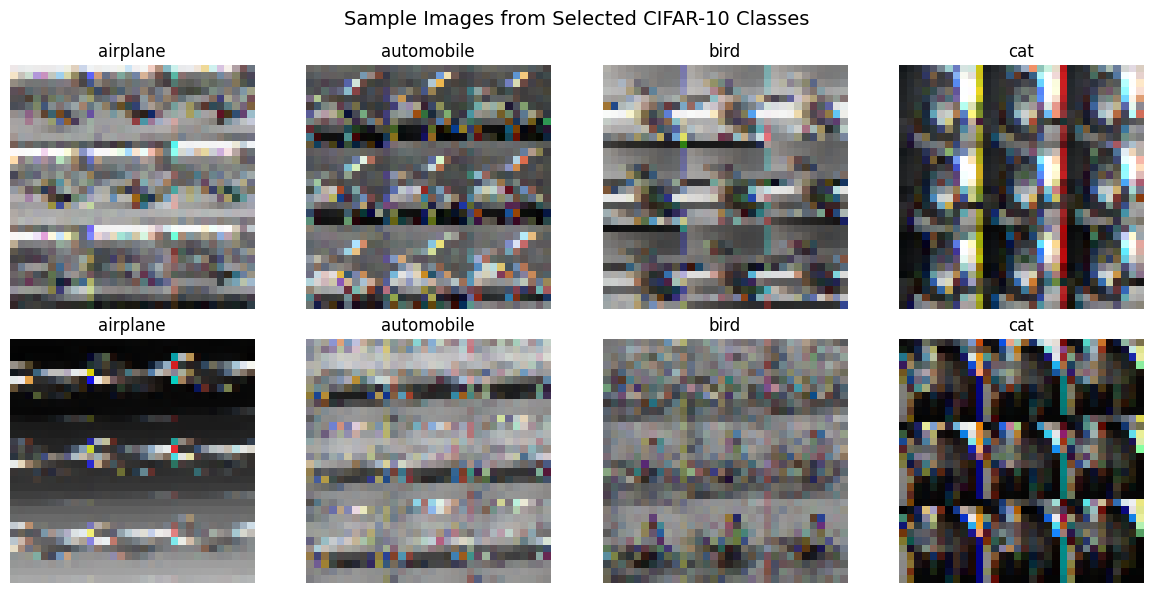

Saved: results/dataset_samples.png


In [ ]:
import os

# create results directory if it doesn't exist
os.makedirs("results", exist_ok=True)

# ============================================================
# Visualize Sample Images
# ============================================================
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, cls in enumerate(SELECTED_CLASSES):
    cls_mask = y_train == cls
    sample_idx = np.where(cls_mask)[0][:2]

    for j, idx in enumerate(sample_idx):
        img = X_train_raw[idx].reshape(32, 32, 3)
        axes[j, i].imshow(img)
        axes[j, i].set_title(CLASS_NAMES[i])
        axes[j, i].axis("off")

plt.suptitle("Sample Images from Selected CIFAR-10 Classes", fontsize=14)
plt.tight_layout()

plt.savefig("results/dataset_samples.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: results/dataset_samples.png")

The visualization shows sample images from each selected class. Note the significant intra-class variation (different viewpoints, backgrounds, scales) — this is exactly the kind of variation that latent subcategories aim to capture.